In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay



3 models + compare

In [3]:
data = "https://raw.githubusercontent.com/ananyaghorpade29/titanic/refs/heads/main/data/Titanic-Dataset.csv"
df = pd.read_csv(data)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.drop(columns=["Cabin"], inplace=True, errors='ignore')
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median()))
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])


In [5]:
x= df.drop(columns=["Name","PassengerId","Ticket","Survived"])
y = df["Survived"]

In [6]:
categorical_col = ["Sex","Embarked"]
numerical_col = ["Age","Pclass","Fare","SibSp","Parch"]


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"),categorical_col),
        ("num", "passthrough",numerical_col)
    ]
)

x_train, x_test, y_train, y_test= train_test_split(
    x,y,test_size=0.2, random_state=42, stratify=y
)


LogisticRegression
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



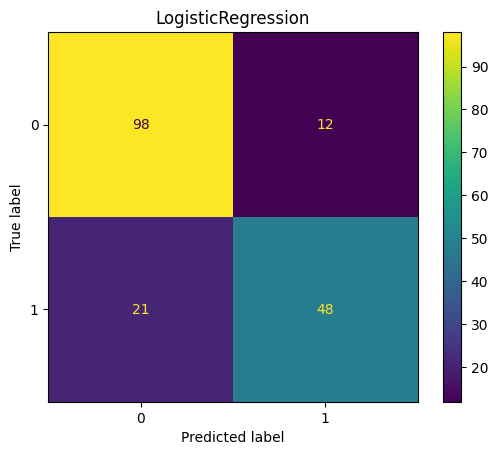


Decision Tree
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



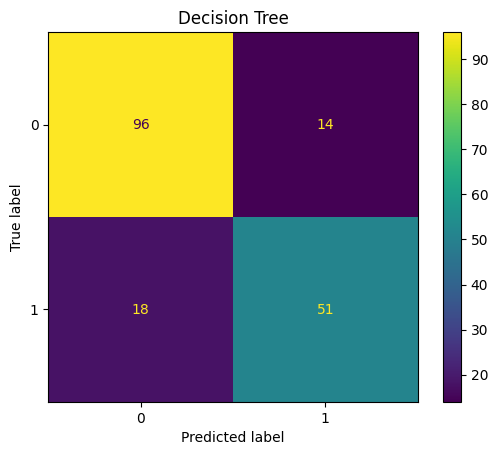


Random Forest
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       110
           1       0.84      0.62      0.72        69

    accuracy                           0.81       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.81      0.81      0.80       179



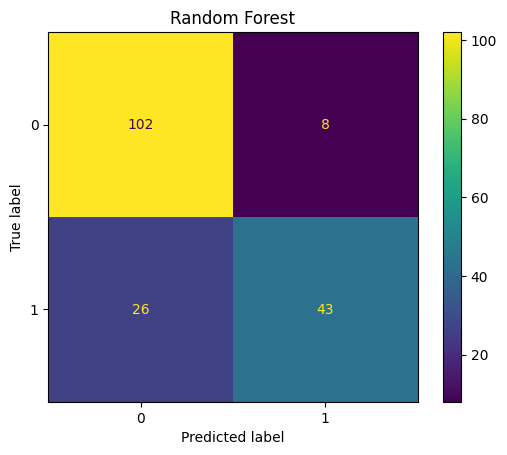

Logistic Regression — decent baseline, ~78-80% accuracy, least likely to overfit 
Decision Tree — will likely show high train accuracy but drop on test (overfitting), unless depth is limited 
Random Forest — will probably be your best performer, ~81-83% accuracy, more robust


In [8]:
models = {"LogisticRegression": LogisticRegression(max_iter=1000),
          "Decision Tree": DecisionTreeClassifier(random_state=42),
          "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)}

result=[]
for name,model in models.items():
    pipeline= Pipeline(steps=[
        ("preprocessing",preprocessor),
        ("model",model)
    ])
    
    pipeline.fit(x_train,y_train)
    y_pred= pipeline.predict(x_test)
    y_train_pred = pipeline.predict(x_train)
    train_acc = accuracy_score(y_train, y_train_pred)  # add accuracy to imports
    
    print(f"\n{name}")
    print(classification_report( y_test, y_pred))
    
    ConfusionMatrixDisplay.from_estimator(pipeline, x_test, y_test)
    plt.title(name)
    plt.show()
    
    report= classification_report(y_test,y_pred, output_dict=True)
    
    result.append({
        "Model": name,
        "Accuracy":report["accuracy"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1 Score": report["weighted avg"]["f1-score"]
    })
    
    


print("Logistic Regression — decent baseline, ~78-80% accuracy, least likely to overfit \nDecision Tree — will likely show high train accuracy but drop on test (overfitting), unless depth is limited \nRandom Forest — will probably be your best performer, ~81-83% accuracy, more robust")

In [9]:
result_df = pd.DataFrame(result)
result_df = result_df.sort_values(by="F1 Score",ascending=False)
result_df.round(2)


,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.82,0.82,0.82,0.82
0,LogisticRegression,0.82,0.81,0.82,0.81
2,Random Forest,0.81,0.81,0.81,0.80


Cross-validation + feature importance

In [10]:
#Cross-validation provides a more robust estimate of model performance by reducing variance from a single train-test split
best_pipeline = Pipeline(steps=[
    ("preprocessing",preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])
cv_score = cross_val_score(best_pipeline,x,y, scoring= "accuracy")

print("CV Scores: ", cv_score)
print("Mean Accuracy: ",cv_score.mean())
print("Std Dev: ",cv_score.std())


CV Scores:  [0.79329609 0.78651685 0.86516854 0.7752809  0.83146067]
Mean Accuracy:  0.810344611135522
Std Dev:  0.03328491924079567


In [12]:
best_pipeline.fit(x_train, y_train)
encoded_features= best_pipeline.named_steps['preprocessing'].get_feature_names_out()
importances= best_pipeline.named_steps["model"].feature_importances_

In [14]:
feat_imp = pd.DataFrame({
    "Features": encoded_features,
    "Importances": importances
}).sort_values(by="Importances",ascending=True)


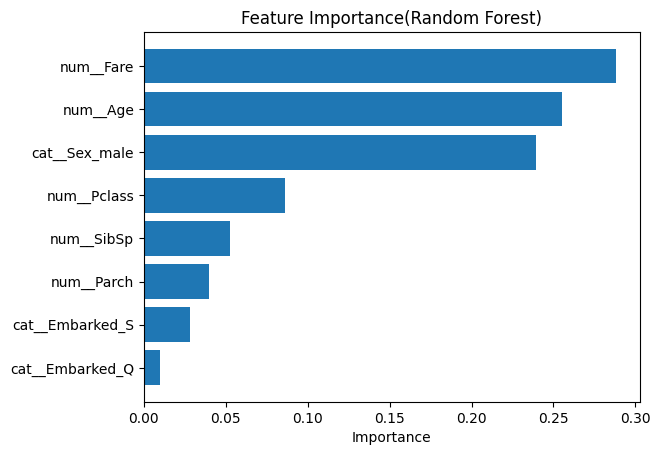

“Features like Embarked and family size have lower importance, 
suggesting they contribute less to prediction compared to core demographic features.


In [20]:
plt.figure()
plt.barh(feat_imp["Features"],feat_imp["Importances"])
plt.xlabel("Importance")
plt.title("Feature Importance(Random Forest)")
plt.show()

print("“Features like Embarked and family size have lower importance, \nsuggesting they contribute less to prediction compared to core demographic features.")